<a href="https://colab.research.google.com/github/SathyaPrakashD/MachineLearning/blob/main/4_2_Confusion_Table_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Import the pandas library for data manipulation
import pandas as pd
# Import the numpy library for numerical operations
import numpy as np

# Import the matplotlib.pyplot library for plotting
import matplotlib.pyplot as plt

In [26]:
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Import DictVectorizer for one-hot encoding categorical features
from sklearn.feature_extraction import DictVectorizer
# Import LogisticRegression for building the classification model
from sklearn.linear_model import LogisticRegression

In [27]:
# Import the kagglehub library to access Kaggle datasets
import kagglehub

# Download the latest version of the dataset using kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# Print the path where the dataset files are located
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [28]:
# Import the pandas library for data manipulation
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Display the DataFrame to show its contents
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [29]:
# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Identify categorical columns (object dtype)
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
for c in categorical_columns:
  # Convert values in categorical columns to lowercase and replace spaces with underscores
    df[c] = df[c].str.lower().str.replace(' ', '_')

# Convert 'totalcharges' to numeric, coercing errors to NaN
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
# Fill any missing 'totalcharges' values with 0
df.totalcharges = df.totalcharges.fillna(0)
# Convert 'churn' column from 'yes'/'no' to 1/0 integers
df.churn = (df.churn == 'yes').astype(int)

In [30]:
# Split data into full training (80%) and test (20%) sets
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
# Split full training into training (75% of full train) and validation (25% of full train) sets
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# Reset index for training DataFrame
df_train = df_train.reset_index(drop=True)
# Reset index for validation DataFrame
df_val = df_val.reset_index(drop=True)
# Reset index for test DataFrame
df_test = df_test.reset_index(drop=True)

# Extract 'churn' target variable for training set
y_train = df_train.churn.values
# Extract 'churn' target variable for validation set
y_val = df_val.churn.values
# Extract 'churn' target variable for test set
y_test = df_test.churn.values

# Remove 'churn' column from training features
del df_train['churn']
# Remove 'churn' column from validation features
del df_val['churn']
# Remove 'churn' column from test features
del df_test['churn']

In [31]:
# Define list of numerical features
numerical = ['tenure', 'monthlycharges', 'totalcharges']

# Define list of categorical features
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [32]:
# Initialize DictVectorizer for one-hot encoding, ensuring dense output
dv = DictVectorizer(sparse=False)

# Convert training data features to a list of dictionaries
train_dict = df_train[categorical + numerical].to_dict(orient='records')
# Fit DictVectorizer and transform training data
X_train = dv.fit_transform(train_dict)

# Initialize Logistic Regression model
model = LogisticRegression()
# Train the Logistic Regression model using the transformed training features and target variable
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

This code block calculates the predicted probabilities of churn for the validation set and then converts these probabilities into binary churn decisions based on a 0.5 threshold.

*   `y_pred = model.predict_proba(X_val)[:, 1]`: This line uses the trained `model` to predict the probability of churn for each customer in the `X_val` (validation) dataset. `predict_proba()` returns probabilities for both classes, and `[:, 1]` selects only the probabilities for the positive class (churn).
*   `churn_decision = (y_pred >= 0.5)`: This line converts the predicted probabilities into a binary decision. If a customer's churn probability (`y_pred`) is 0.5 or higher, `churn_decision` for that customer will be `True` (predicted to churn); otherwise, it will be `False` (predicted not to churn). This operation is element-wise, meaning the `churn_decision` array has the same length as `y_pred` and `y_val`.

In [34]:
# Convert validation data features to a list of dictionaries
val_dict = df_val[categorical + numerical].to_dict(orient='records')
# Transform validation data using the fitted DictVectorizer
X_val = dv.transform(val_dict)

# Get predicted probabilities for the positive class (churn=1) on the validation set
y_pred = model.predict_proba(X_val)[:, 1]
print(y_pred.round(3))
print(len(y_pred))

# Classify as churn if probability is 0.5 or higher
churn_decision = (y_pred >= 0.5)
print(len(churn_decision))

# Calculate the accuracy of the model on the validation set
(y_val == churn_decision).mean()

[0.008 0.21  0.224 ... 0.15  0.777 0.81 ]
1409
1409


np.float64(0.801277501774308)

## Accuracy and dummy Model

- Evaluate the model on different thresholds
- Arranging them in a table

In [35]:
len(y_val)

1409

This line calculates the accuracy of the model on the validation set.

*   `(y_val == churn_decision)`: This performs an element-wise comparison between the actual churn values (`y_val`, which are 0s and 1s) and the model's predicted churn decisions (`churn_decision`, which are True/False). It creates a new boolean array where `True` indicates a correct prediction and `False` indicates an incorrect prediction.
*   `.mean()`: When applied to a boolean array, `.mean()` treats `True` as 1 and `False` as 0. Therefore, the result is the proportion of `True` values, which represents the overall accuracy of the model.

In [36]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

This line calculates the total number of correct predictions made by the model on the validation set.

*   `(y_val == churn_decision)`: Similar to the accuracy calculation, this creates a boolean array where `True` indicates a correct prediction and `False` an incorrect one.
*   `.sum()`: When applied to a boolean array, `.sum()` treats `True` as 1 and `False` as 0. Therefore, the result is the total count of `True` values, representing the absolute number of correct predictions.

In [38]:
(y_val == churn_decision).sum()

np.int64(1129)

In [39]:
1129/1409

0.801277501774308

This is the accuracy. total number of correct prediction divided by total number of prediction in y_val.

 We classified the churn decision threshold. If probability is 0.5 or higher.
churn_decision = (y_pred >= 0.5)

Let us see, if increasing or decreasing the threshold from 0.5 will increase or decrease the threshold.

Lets create a array of threshold using linspace.

In [48]:
thresholds = np.linspace(0, 2, 21)
thresholds

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

Lets iterate over array of thresholds

In [49]:
scores = []

for t in thresholds:
  churn_decision = (y_pred >= t)
  score = (y_val == churn_decision).mean()
  scores.append(score)
  #print(t, "-- " ,(y_val == churn_decision).mean())
  print('%.2f %.3f' % (t,score))


0.00 0.274
0.10 0.598
0.20 0.707
0.30 0.759
0.40 0.780
0.50 0.801
0.60 0.797
0.70 0.765
0.80 0.730
0.90 0.726
1.00 0.726
1.10 0.726
1.20 0.726
1.30 0.726
1.40 0.726
1.50 0.726
1.60 0.726
1.70 0.726
1.80 0.726
1.90 0.726
2.00 0.726


From the above the output we see  that 0.5 is infact the best threshold

**0.5 - 0.801**

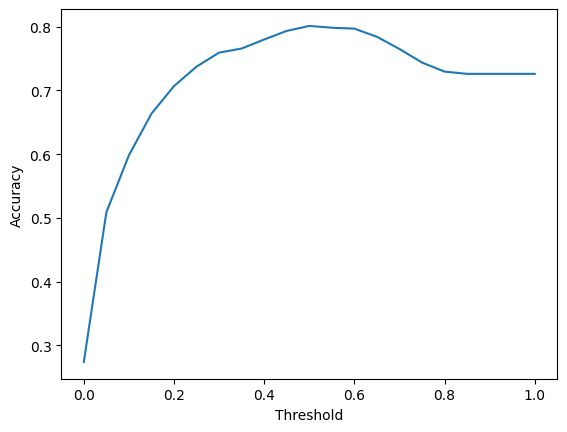

In [45]:
plt.plot(thresholds, scores)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.show()
#

- Above graph tells that there is no customer churns for Threashold above 1.0.

- For a model with threshold = 1.0 has the accuracy of 73%.

Important question to observe.

- A Dummy model with threshold greater or equal to 1.0 has a accuracy of 0.73 or 73% and the above trained model has a accuracy of 80%.

- **Why do we need to train the model for only 7% difference in performance**

  - This is the main issue with Accuracy. Accuracy doesn't tell us about the performance of the model.

  - As per the class distribution in the data only 27% of the users are churning and remaining 73% are non-chruning. So there is almost 3:1 class imbalance between churning and non-chruning users.

# Week 4 — Accuracy & Dummy Models: Session Notes
**Source:** ML Zoomcamp Week 4, Video 1  
**Topic:** Accuracy, Threshold Tuning, Class Imbalance, Dummy Models  
**Status:** Concepts locked ✅

---

## Q1 — What happens when threshold is set to 1.0?

**Q:** In the video, why does he say the customer is churning if the threshold is above 1.0?

**A:** He is saying the opposite. When the threshold is set to 1.0, a customer is classified as churning **only if their score ≥ 1.0**. Since logistic regression outputs probabilities that never actually reach 1.0, no customer ever crosses that line. The model predicts **nobody churns** — it becomes a do-nothing model. The Counter confirmed this: zero True values, all False.

---

## Q2 — What does the Counter result prove?

**Q:** What did the Counter result actually show?

**A:** The Counter found **zero churns**. Every single prediction was False (non-churning). The model with threshold = 1.0 did not flag a single customer as churning.

---

## Q3 — Why is 80% accuracy a problem on this dataset?

**Q:** The model scored 80%. A dummy model scored 73%. Why is that a problem?

**A:** Accuracy is driven by the percentage split in the data classes. On highly imbalanced data, a do-nothing model already scores high because it accidentally gets the majority class right every time. The gap between the real model (80%) and the dummy model (73%) is only 7% — which means the real model is barely doing anything useful beyond predicting the majority class. **Accuracy cannot be the lead metric on imbalanced data.**

> **Rule:** Dummy model accuracy = majority class percentage. Always.

---

## Q4 — What happens to accuracy when classes are perfectly balanced?

**Q:** If the class is exactly balanced (50/50), will accuracy still default to 50%?

**A:** Yes. The dummy model that predicts "nobody churns" would score exactly **50% accuracy** on balanced data — because there is no majority class to exploit. This also means accuracy becomes **more trustworthy** on balanced data. A model scoring 80% on balanced data genuinely earned those points. The same 80% on imbalanced data may be nearly worthless.

> **Rule:** The more imbalanced the data, the more accuracy lies to you.

---

## Q5 — What does "the model is doing something useful" mean?

**Q:** What does it mean when you say a model scoring 80% on balanced data is "doing something useful"?

**A:** Compare the real model against the do-nothing baseline:
- **Balanced data:** Dummy = 50%, Real = 80%. Gap = **30%.** The model earned those 30 points through actual skill.
- **Imbalanced data:** Dummy = 73%, Real = 80%. Gap = **7%.** The model barely had to work.

The gap between the real model and the dummy model is what tells you if the model is actually working — not the raw accuracy number.

---

## Q6 — What does the dummy model actually predict?

**Q:** The dummy model predicts 73% of non-churners correctly and 27% of churners correctly. Is that right?

**A:** Not quite. The dummy model predicts **everyone as non-churning** — no exceptions.
- **73% who actually don't churn** → called non-churning → ✅ Correct. All of them.
- **27% who actually do churn** → also called non-churning → ❌ Wrong. Every single one.

The dummy model gets **zero churners right.** The 73% accuracy comes entirely from the non-churning majority — not from any skill on churners.

> **Analogy:** A doctor who tells every patient "you're healthy." Correct for the healthy ones. Dangerously wrong for every sick patient.

---

## Q7 — Did the dummy model come into existence because of the 1.0 threshold?

**Q:** Dummy model comes into existence when threshold is set to 1.0. Is that correct?

**A:** Not quite. They are two separate things that produce the same result.
- **The dummy model** is a deliberate baseline — built intentionally to always predict the majority class. A benchmark.
- **The 1.0 threshold** accidentally recreated the dummy model's behaviour during threshold sweeping.

Same output. Different intent. In sklearn, you build a dummy model explicitly:
```python
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
```

---

## Q8 — How does threshold 0.5 differ from threshold 1.0?

**Q:** How does a model with threshold 0.5 differ from a model with threshold 1.0?

**A:** Same model. Same scores. Different decision line.

```
Threshold 0.5:
0 ────────────────|────────────── 1
                 0.5
         Not churn | Churn
→ Customers above 0.5 flagged as churning. Result: 80% accuracy.

Threshold 1.0:
0 ──────────────────────────────| 1
                                1.0
                    Not churn   | Churn
→ Nobody scores ≥ 1.0. Nobody flagged as churning. Result: 73% accuracy.
```

The underlying model and scores did not change. Only the line moved.

---

## Q9 — Why does accuracy drop as threshold moves right of 0.5?

**Q:** As the threshold moved right from 0.5, accuracy dropped to 73%. Why?

**A:** At 0.5, the model correctly identifies some churners and some non-churners. As the threshold moves right:
- Customers with scores between 0.5 and the new threshold — previously called churning — now fall on the non-churning side.
- Some of those customers actually churn → they are now missed.
- Correct churn predictions shrink one by one until at 1.0 they reach zero.

```
Correct churners caught at 0.5:  ████████░░  
Correct churners caught at 0.7:  █████░░░░░  
Correct churners caught at 1.0:  ░░░░░░░░░░  ← zero
```

Moving left of 0.5 has the opposite effect: non-churners start getting flagged as churning, producing false alarms and dropping accuracy on the non-churning side.

---

## Q10 — What does the threshold actually control?

**Q:** So the threshold controls the decision line, and the score is fixed by the customer's features?

**A:** Exactly. Four stages, in order:

```
Features → Score → Threshold → Decision
```

- **Features** (customer data) → determine the **score** (fixed by the model, never changes)
- **Threshold** (the decision line) → determines the **decision** (churn or not churn)

The threshold controls eligibility — which side of the line a customer falls on. It does not change the score. Moving the threshold changes the decision, not the underlying probability.

---

## Key Rules to Remember

| Rule | Statement |
|---|---|
| Dummy model accuracy | Always equals the majority class percentage |
| Accuracy on imbalanced data | Reflects class distribution, not model skill |
| Threshold | Controls the decision line only — scores are fixed |
| Real model vs dummy gap | This gap — not raw accuracy — tells you if the model is working |
| Accuracy trustworthiness | The more imbalanced the data, the more accuracy lies to you |

---

## Concepts Locked This Session ✅

- Accuracy reflects class distribution, not model skill
- Dummy model accuracy = majority class percentage
- On imbalanced data, accuracy hides complete failure on the minority class
- Dummy model and 1.0 threshold are different things with the same outcome
- Threshold controls the decision line; score is fixed by features